In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


# Jailson simulation's

In [2]:
# ============================================================
# 1) Retardance model
# ============================================================

def retardance_from_wavelength(lambda_nm, lambda0_nm, delta0_rad=np.pi/2):
    """
    Simple model:
        delta(lambda) ~ delta(lambda0) * lambda0 / lambda
    """
    return delta0_rad * (lambda0_nm / lambda_nm)


# ============================================================
# 2) General intensity model
# ============================================================

def intensity_model_general(theta_rad, S, delta_rad):
    """
    General polarimeter intensity for a retarder with arbitrary retardance.
    """
    S0, S1, S2, S3 = S
    c = np.cos(delta_rad)
    s = np.sin(delta_rad)

    return (
        0.5 * S0
        + 0.25 * S1 * ((1.0 + c) + (1.0 - c) * np.cos(4.0 * theta_rad))
        + 0.25 * S2 * (1.0 - c) * np.sin(4.0 * theta_rad)
        - 0.5 * S3 * s * np.sin(2.0 * theta_rad)
    )


# ============================================================
# 3) Quadrant-dependent retardance
# ============================================================

def quadrant_retardance(theta_rad, lambda_laser_nm, lambda0_quadrants_nm, phase_offset_deg=0.0):
    """
    Return the retardance at each angle theta according to which quadrant
    is under the beam.

    Parameters
    ----------
    theta_rad : array
        Rotation angles.
    lambda_laser_nm : float
        Laser wavelength.
    lambda0_quadrants_nm : list or array of length 4
        Design wavelength of each quadrant, in order:
        [Q1, Q2, Q3, Q4]
    phase_offset_deg : float
        Allows rotating the quadrant map relative to theta=0.
    """
    theta_eff = (theta_rad + np.deg2rad(phase_offset_deg)) % (2 * np.pi)
    quadrant_index = np.floor(theta_eff / (np.pi / 2)).astype(int)  # 0,1,2,3

    lambda0_local = np.array(lambda0_quadrants_nm)[quadrant_index]
    delta_local = retardance_from_wavelength(lambda_laser_nm, lambda0_local)

    return delta_local, quadrant_index


# ============================================================
# 4) Fixed polarization states
# ============================================================

def stokes_from_azimuth_ellipticity(psi_deg, chi_deg, S0=1.0):
    psi = np.deg2rad(psi_deg)
    chi = np.deg2rad(chi_deg)

    s1 = np.cos(2.0 * chi) * np.cos(2.0 * psi)
    s2 = np.cos(2.0 * chi) * np.sin(2.0 * psi)
    s3 = np.sin(2.0 * chi)

    return np.array([S0, S0 * s1, S0 * s2, S0 * s3])


def get_fixed_polarization(
    polarization_type="elliptical",
    S0=1.0,
    linear_angle_deg=30.0,
    circular_hand=+1,
    ellipse_azimuth_deg=25.0,
    ellipse_chi_deg=20.0
):
    p = polarization_type.lower()

    if p == "linear":
        return stokes_from_azimuth_ellipticity(linear_angle_deg, 0.0, S0)

    elif p == "circular":
        chi = 45.0 if circular_hand >= 0 else -45.0
        return stokes_from_azimuth_ellipticity(0.0, chi, S0)

    elif p == "elliptical":
        return stokes_from_azimuth_ellipticity(ellipse_azimuth_deg, ellipse_chi_deg, S0)

    else:
        raise ValueError("Use 'linear', 'circular', or 'elliptical'.")


def normalize_stokes(S):
    S0, S1, S2, S3 = S
    return np.array([S1 / S0, S2 / S0, S3 / S0])


# ============================================================
# 5) Simple global fit with a single effective delta
# ============================================================

def fit_stokes_from_curve_general(theta_rad, I_theta, delta_rad):
    """
    Reconstruct Stokes assuming a single retardance delta_rad.
    This is exact for a uniform plate, but only approximate for a
    quadrant-dependent plate.
    """
    A = np.column_stack([
        np.ones_like(theta_rad),
        np.sin(2.0 * theta_rad),
        np.cos(4.0 * theta_rad),
        np.sin(4.0 * theta_rad),
    ])

    coeffs, *_ = np.linalg.lstsq(A, I_theta, rcond=None)
    a0, a2, a4c, a4s = coeffs

    c = np.cos(delta_rad)
    s = np.sin(delta_rad)

    S1 = 4.0 * a4c / (1.0 - c)
    S2 = 4.0 * a4s / (1.0 - c)
    S3 = -2.0 * a2 / s
    S0 = 2.0 * a0 - 2.0 * a4c * (1.0 + c) / (1.0 - c)

    return np.array([S0, S1, S2, S3]), coeffs


# ============================================================
# 6) Poincare sphere
# ============================================================

def plot_poincare_sphere(ax, s_true, s_fit):
    u = np.linspace(0, 2 * np.pi, 80)
    v = np.linspace(0, np.pi, 40)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(x, y, z, rstride=4, cstride=4, alpha=0.12)

    ax.plot([-1, 1], [0, 0], [0, 0], lw=1)
    ax.plot([0, 0], [-1, 1], [0, 0], lw=1)
    ax.plot([0, 0], [0, 0], [-1, 1], lw=1)

    ax.scatter(s_true[0], s_true[1], s_true[2], s=90, label="True point")
    ax.plot([0, s_true[0]], [0, s_true[1]], [0, s_true[2]], lw=2)

    ax.scatter(s_fit[0], s_fit[1], s_fit[2], s=90, label="Fitted point")
    ax.plot([0, s_fit[0]], [0, s_fit[1]], [0, s_fit[2]], "--", lw=2)

    ax.set_xlabel("s1")
    ax.set_ylabel("s2")
    ax.set_zlabel("s3")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect((1, 1, 1))
    ax.set_title("Poincare sphere")
    ax.legend()




QUADRANT-DEPENDENT RETARDANCE SIMULATION
Laser wavelength = 633.0 nm
Quadrant design wavelengths = [610.0, 650.0, 610.0, 650.0]
delta_630(810) = 1.221730 rad
delta_650(810) = 1.260516 rad

True normalized Stokes:
[-1.0000000e+00  1.2246468e-16  0.0000000e+00]
Fitted normalized Stokes:
[-1.00000000e+00  1.18758323e-16  4.21068557e-02]


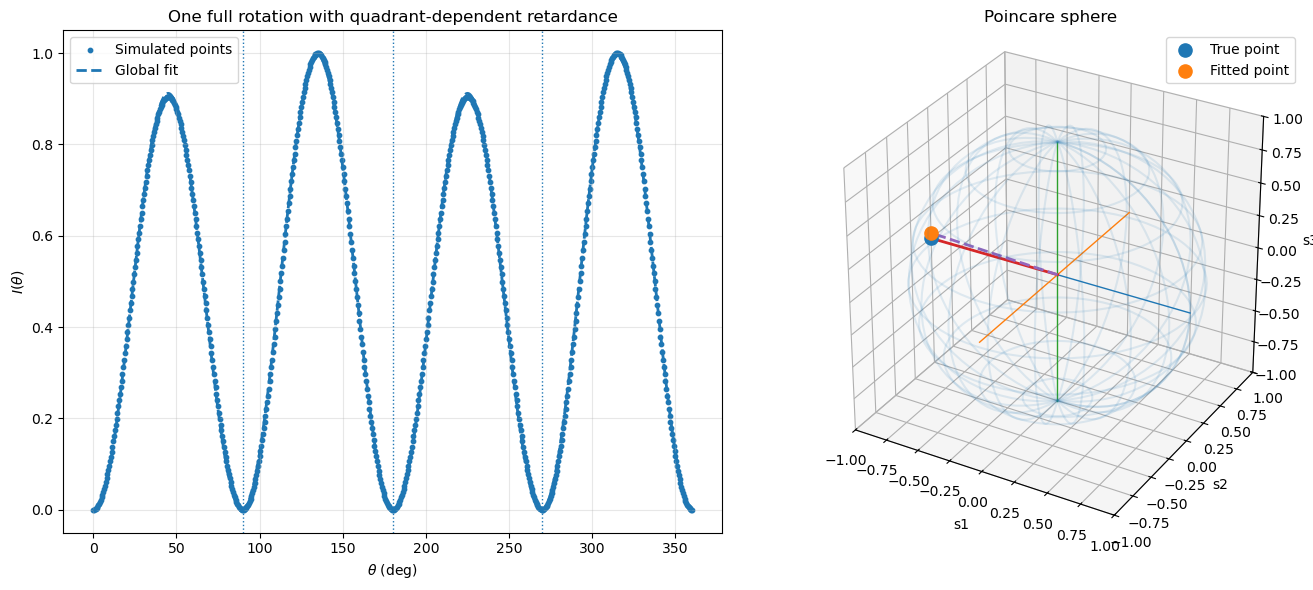

In [3]:
if __name__ == "__main__":

    # Laser wavelength
    lambda_laser_nm = 633.0

    # Example quadrant map:
    # Q1 = 630 nm, Q2 = 650 nm, Q3 = 630 nm, Q4 = 650 nm
    lambda0_quadrants_nm = [610.0, 650.0, 610.0, 650.0]

    # Choose a fixed polarization state
    polarization_type = "linear"   # "linear", "circular", "elliptical"

    S_true = get_fixed_polarization(
        polarization_type=polarization_type,
        S0=1.0,
        linear_angle_deg=90.0,
        circular_hand=+1,
        ellipse_azimuth_deg=25.0,
        ellipse_chi_deg=20.0
    )

    # One full rotation
    theta_deg = np.linspace(0.0, 360.0, 721)
    theta_rad = np.deg2rad(theta_deg)

    # Local retardance seen by the beam at each angle
    delta_local, quadrant_index = quadrant_retardance(
        theta_rad,
        lambda_laser_nm=lambda_laser_nm,
        lambda0_quadrants_nm=lambda0_quadrants_nm,
        phase_offset_deg=0.0
    )

    # Simulate the signal with quadrant-dependent retardance
    I_sim = np.array([
        intensity_model_general(theta_rad[i], S_true, delta_local[i])
        for i in range(len(theta_rad))
    ])
    I_sim = I_sim / np.max(I_sim)
    # Use a single effective delta only for a simple global fit
    delta_eff = np.mean(delta_local)
    S_fit, coeffs = fit_stokes_from_curve_general(theta_rad, I_sim, delta_eff)
    I_fit = intensity_model_general(theta_rad, S_fit, delta_eff)

    s_true = normalize_stokes(S_true)
    s_fit = normalize_stokes(S_fit)

    print("=" * 70)
    print("QUADRANT-DEPENDENT RETARDANCE SIMULATION")
    print("=" * 70)
    print(f"Laser wavelength = {lambda_laser_nm:.1f} nm")
    print(f"Quadrant design wavelengths = {lambda0_quadrants_nm}")
    print(f"delta_630(810) = {retardance_from_wavelength(810.0, 630.0):.6f} rad")
    print(f"delta_650(810) = {retardance_from_wavelength(810.0, 650.0):.6f} rad")
    print()
    print("True normalized Stokes:")
    print(s_true)
    print("Fitted normalized Stokes:")
    print(s_fit)

    fig = plt.figure(figsize=(14, 6))

    ax1 = fig.add_subplot(1, 2, 1)
    ax1.scatter(theta_deg, I_sim, s=10, label="Simulated points")
    ax1.plot(theta_deg, I_fit, "--", lw=2, label="Global fit")
    ax1.set_xlabel(r"$\theta$ (deg)")
    ax1.set_ylabel(r"$I(\theta)$")
    ax1.set_title("One full rotation with quadrant-dependent retardance")
    ax1.grid(alpha=0.3)
    ax1.legend()

    # mark quadrant boundaries
    for ang in [90, 180, 270]:
        ax1.axvline(ang, ls=":", lw=1)

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    plot_poincare_sphere(ax2, s_true, s_fit)

    plt.tight_layout()
    plt.show()

Fitted coefficients = [ 4.76199508e-01 -4.04049706e-02 -4.76199508e-01  5.65526552e-17]
Reconstructed Stokes = [ 2.87103894e+00 -2.87103894e+00  3.40959771e-16  8.58158820e-02]
Normalized Stokes = [-1.00000000e+00  1.18758323e-16  2.98901839e-02]


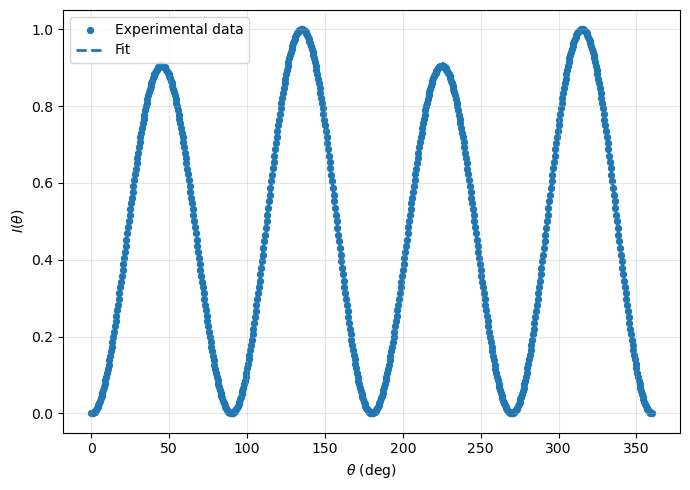

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#somente o fit

def retardance_from_wavelength(lambda_nm, lambda0_nm=633.0, delta0_rad=np.pi/2):
  return delta0_rad * (lambda0_nm / lambda_nm)


def fit_harmonic_model(theta_rad, I_data):
  A = np.column_stack([
  np.ones_like(theta_rad),
  np.sin(2.0 * theta_rad),
  np.cos(4.0 * theta_rad),
  np.sin(4.0 * theta_rad),
  ])
  coeffs, *_ = np.linalg.lstsq(A, I_data, rcond=None)
  return coeffs


def reconstruct_stokes_from_coeffs(a0, a2, a4c, a4s, delta_rad):
  c = np.cos(delta_rad)
  s = np.sin(delta_rad)
  S1 = 4.0 * a4c / (1.0 - c)
  S2 = 4.0 * a4s / (1.0 - c)
  S3 = -2.0 * a2 / s
  S0 = 2.0 * a0 - 2.0 * a4c * (1.0 + c) / (1.0 - c)
  return np.array([S0, S1, S2, S3])

def normalize_stokes(S):
  S0, S1, S2, S3 = S
  return np.array([S1/S0, S2/S0, S3/S0])


def harmonic_model(theta_rad, coeffs):
  a0, a2, a4c, a4s = coeffs
  return a0 + a2*np.sin(2*theta_rad) + a4c*np.cos(4*theta_rad) + a4s*np.sin(4*
  theta_rad)

# Replace these arrays with your experimental data
theta_rad = np.deg2rad(theta_deg)
# Fit
coeffs = fit_harmonic_model(theta_rad, I_sim)
a0, a2, a4c, a4s = coeffs
# Retardance
lambda_design_nm = 633.0
lambda_laser_nm = 810.0
delta_rad = retardance_from_wavelength(lambda_laser_nm, lambda_design_nm)
# Reconstruct Stokes
S = reconstruct_stokes_from_coeffs(a0, a2, a4c, a4s, delta_rad)
s = normalize_stokes(S)
print("Fitted coefficients =", coeffs)
print("Reconstructed Stokes =", S)
print("Normalized Stokes =", s)



# Plot
theta_fit = np.linspace(theta_rad.min(), theta_rad.max(), 1000)
I_fit = harmonic_model(theta_fit, coeffs)
plt.figure(figsize=(7,5))
plt.scatter(theta_deg, I_sim, s=18, label="Experimental data")
plt.plot(np.rad2deg(theta_fit), I_fit, "--", lw=2, label="Fit")
plt.xlabel(r"$\theta$ (deg)")
plt.ylabel(r"$I(\theta)$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

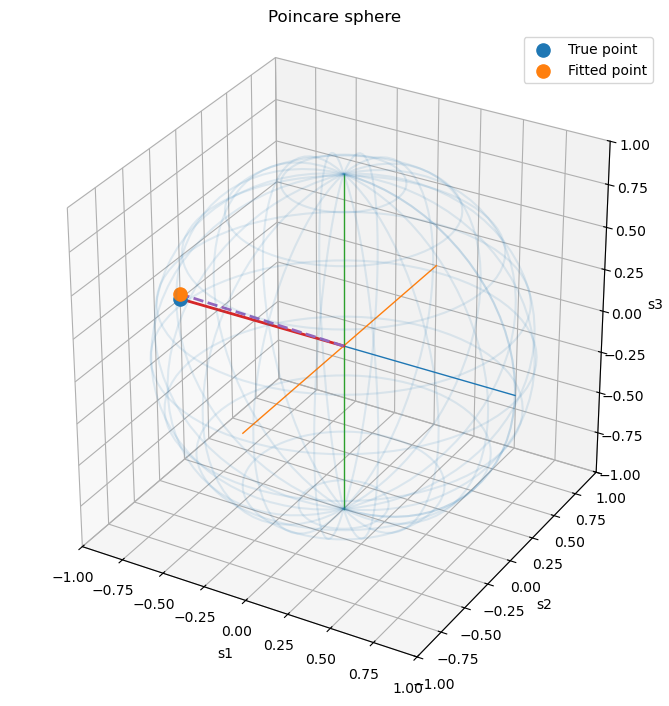

In [5]:
fig_new = plt.figure(figsize=(7, 7))
ax_new = fig_new.add_subplot(111, projection='3d')
plot_poincare_sphere(ax_new, s_true, s)
plt.tight_layout()
plt.show()

# Analisis taking into account $\delta$

In [6]:
medicion = pd.read_csv('Measurements\\medicion_manual_v0.1.csv')
I_med = medicion['voltaje']
theta = medicion['angulo']*np.pi/180
medicion.head()

,angulo,voltaje
0,0,0.036397
1,2,0.033974
2,4,0.029945
3,6,0.026009
4,8,0.023342


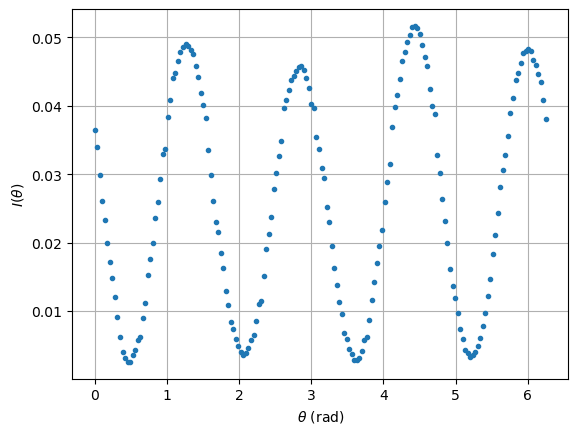

In [7]:
# --- Plot of the measurments ---
plt.figure()
plt.plot(theta,I_med,'.')

plt.xlabel(r"$\theta$ (rad)")
plt.ylabel(r"$I(\theta)$")
plt.grid()

## Harmonic fit


Coefficients:
a0 = 0.0259037644444444
a2 = 0.0008084320856486915
a4c = 0.008477267313071973
a4s = -0.021061336212103453

delta (rad) = 1.8684208939770874

Reconstructed Stokes parameters:
S0 = 0.0518075288888888
S1 = 0.02622004119239566
S2 = -0.06514234866661665
S3 = -0.0016912172143833894

DOP = 1.3558175570503466


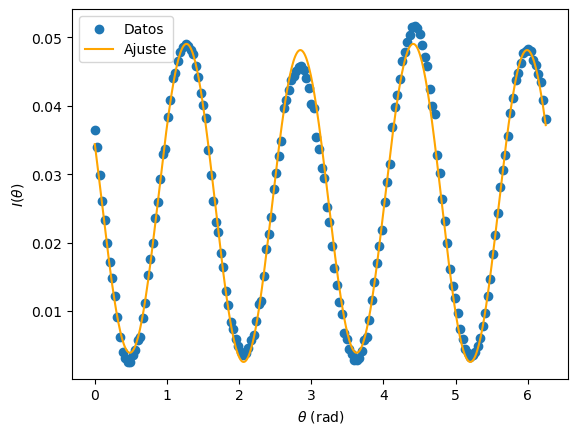

In [8]:

# --- Harmonic fit ---
def fit_harmonic_model(theta_rad, I_data):
    A = np.column_stack([
        np.ones_like(theta_rad),
        np.sin(2.0 * theta_rad),
        np.cos(4.0 * theta_rad),
        np.sin(4.0 * theta_rad),
    ])
    coeffs, *_ = np.linalg.lstsq(A, I_data, rcond=None)
    return coeffs

coeffs = fit_harmonic_model(theta, I_med)
a0, a2, a4c, a4s = coeffs

print("Coefficients:")
print("a0 =", a0)
print("a2 =", a2)
print("a4c =", a4c)
print("a4s =", a4s)

# --- effective stokes ---
S0_eff = 2*a0
S1_eff = 4*a4c
S2_eff = 4*a4s
S3_eff = -2*a2

# --- define wavelengths ---
lambda_design = 632.8e-9   # example: QWP for HeNe
lambda_real   = 532e-9     # example: your laser (change as needed)

# --- calculate delta ---
delta = (np.pi/2) * (lambda_design / lambda_real)

print("\ndelta (rad) =", delta)

# --- reconstruction of real Stokes parameters ---
S0 = S0_eff
S1 = S1_eff / (1 - np.cos(delta))
S2 = S2_eff / (1 - np.cos(delta))
S3 = S3_eff / np.sin(delta)

print("\nReconstructed Stokes parameters:")
print("S0 =", S0)
print("S1 =", S1)
print("S2 =", S2)
print("S3 =", S3)

# --- DOP ---
DOP = np.sqrt(S1**2 + S2**2 + S3**2) / S0
print("\nDOP =", DOP)

# --- fitted model ---
def harmonic_model(theta_rad, coeffs):
    a0, a2, a4c, a4s = coeffs
    return a0 + a2*np.sin(2*theta_rad) + a4c*np.cos(4*theta_rad) + a4s*np.sin(4*theta_rad)

theta_fit = np.linspace(theta.min(), theta.max(), 500)
I_fit = harmonic_model(theta_fit, coeffs)

# --- graph ---
plt.scatter(theta, I_med, label="Datos")
plt.plot(theta_fit, I_fit, color="orange", label="Ajuste")
plt.xlabel(r"$\theta$ (rad)")
plt.ylabel(r"$I(\theta)$")
plt.legend()
plt.show()

## Harmonic fit without changing $S_{eff}$ to $S$

Coeficientes:
a0 = 0.0259037644444444
a2 = 0.0008084320856486915
a4c = 0.008477267313071973
a4s = -0.021061336212103453

delta = 1.8684208939770874

Reconstructed Stokes parameters:
S0 = 0.0518075288888888
S1 = 0.02622004119239566
S2 = -0.06514234866661665
S3 = -0.0016912172143833894

DOP = 1.3558175570503466


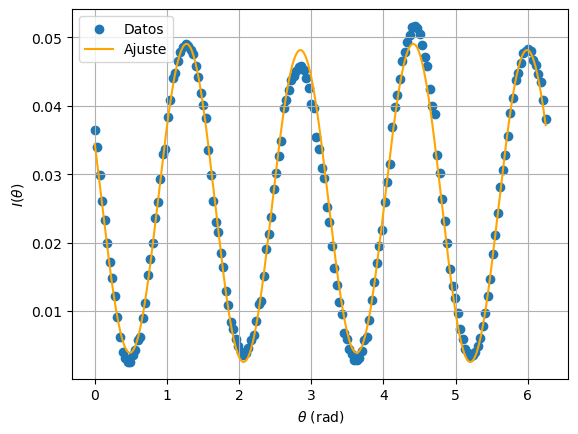

In [9]:
def fit_harmonic_model(theta_rad, I_data):
    A = np.column_stack([
        np.ones_like(theta_rad),
        np.sin(2.0 * theta_rad),
        np.cos(4.0 * theta_rad),
        np.sin(4.0 * theta_rad),
    ])
    coeffs, *_ = np.linalg.lstsq(A, I_data, rcond=None)
    return coeffs

a0, a2, a4c, a4s = fit_harmonic_model(theta, I_med)

print("Coeficientes:")
print("a0 =", a0)
print("a2 =", a2)
print("a4c =", a4c)
print("a4s =", a4s)

# --- define wavelengths ---
lambda_design = 632.8e-9   # CHANGE if needed
lambda_real   = 532e-9     # Your laser wavelength 

# --- calculate delta ---
delta = (np.pi/2) * (lambda_design / lambda_real)
print("\ndelta =", delta)

# --- reconstruction of real Stokes parameters ---
S0 = 2*a0
S1 = 4*a4c / (1 - np.cos(delta))
S2 = 4*a4s / (1 - np.cos(delta))
S3 = -2*a2 / np.sin(delta)

print("\nReconstructed Stokes parameters:")
print("S0 =", S0)
print("S1 =", S1)
print("S2 =", S2)
print("S3 =", S3)

# --- DOP ---
DOP = np.sqrt(S1**2 + S2**2 + S3**2) / S0
print("\nDOP =", DOP)

# --- fitted model ---
def harmonic_model(theta_rad, a0, a2, a4c, a4s):
    return a0 + a2*np.sin(2*theta_rad) + a4c*np.cos(4*theta_rad) + a4s*np.sin(4*theta_rad)

theta_fit = np.linspace(theta.min(), theta.max(), 500)
I_fit = harmonic_model(theta_fit, a0, a2, a4c, a4s)

# --- graph ---
plt.scatter(theta, I_med, label="Datos")
plt.plot(theta_fit, I_fit, color="orange", label="Ajuste")

plt.grid()
plt.xlabel(r"$\theta$ (rad)")
plt.ylabel(r"$I(\theta)$")
plt.legend()
plt.show()

## Consider a different $\delta$ for every quadrant (without adding parameters)


Cuadrante 1
coef = [ 0.03017631 -0.00571956  0.00613196 -0.02123092]
Stokes = [ 0.03564655  0.03696997 -0.12800263  0.01214773]
Normalizado = [ 1.03712607 -3.59088366  0.34078273]

Cuadrante 2
coef = [ 0.02302877 -0.00261201  0.00869362 -0.01951577]
Stokes = [ 0.01103037  0.05241441 -0.1176619   0.00554763]
Normalizado = [  4.75182873 -10.66708932   0.50294171]

Cuadrante 3
coef = [ 0.02274118  0.00582167  0.01060982 -0.0230768 ]
Stokes = [ 0.00273467  0.06396734 -0.1391316  -0.01236461]
Normalizado = [ 23.39123845 -50.87691016  -4.52142671]

Cuadrante 4
coef = [ 0.02922864  0.00516532  0.00743209 -0.02042185]
Stokes = [ 0.02851291  0.04480855 -0.12312473 -0.01097059]
Normalizado = [ 1.57151789 -4.31821007 -0.38475859]

=== PROMEDIO ===
Stokes promedio = [ 0.01948113  0.04954007 -0.12698022 -0.00140996]
Normalizado = [ 2.54297767 -6.51811507 -0.07237569]


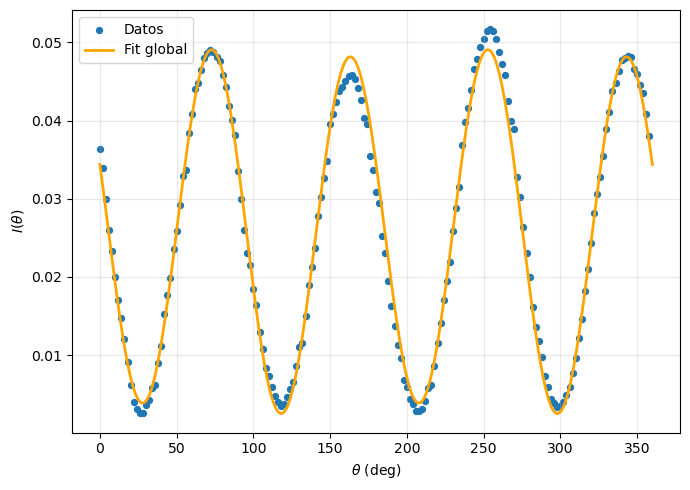

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- retardance ---
def retardance_from_wavelength(lambda_nm, lambda0_nm=633.0, delta0_rad=np.pi/2):
    return delta0_rad * (lambda0_nm / lambda_nm)

# --- separate quadrants ---
def separar_cuadrantes(theta, I_med):
    theta_mod = theta % (2*np.pi)
    
    masks = [
        (theta_mod >= 0) & (theta_mod < np.pi/2),
        (theta_mod >= np.pi/2) & (theta_mod < np.pi),
        (theta_mod >= np.pi) & (theta_mod < 3*np.pi/2),
        (theta_mod >= 3*np.pi/2) & (theta_mod < 2*np.pi),
    ]
    
    data = []
    for m in masks:
        data.append((theta[m], I_med[m]))
    
    return data

# --- harmonic fit ---
def fit_harmonic_model(theta, I_med):
    A = np.column_stack([
        np.ones_like(theta),
        np.sin(2.0 * theta),
        np.cos(4.0 * theta),
        np.sin(4.0 * theta),
    ])
    coeffs, *_ = np.linalg.lstsq(A, I_med, rcond=None)
    return coeffs

# --- reconstruction of Stokes parameters ---
def reconstruct_stokes_from_coeffs(a0, a2, a4c, a4s, delta_rad):
    c = np.cos(delta_rad)
    s = np.sin(delta_rad)
    
    S1 = 4.0 * a4c / (1.0 - c)
    S2 = 4.0 * a4s / (1.0 - c)
    S3 = -2.0 * a2 / s
    S0 = 2.0 * a0 - 2.0 * a4c * (1.0 + c) / (1.0 - c)
    
    return np.array([S0, S1, S2, S3])

# --- normalization ---
def normalize_stokes(S):
    S0, S1, S2, S3 = S
    return np.array([S1/S0, S2/S0, S3/S0])

# --- fitted model ---
def harmonic_model(theta, coeffs):
    a0, a2, a4c, a4s = coeffs
    return a0 + a2*np.sin(2*theta) + a4c*np.cos(4*theta) + a4s*np.sin(4*theta)

# =========================
# YOUR DATA
# =========================

# --- separate in quadrants ---
cuadrantes = separar_cuadrantes(theta, I_med)

# --- wavelengths ---
lambda_design_nm = 633.0
lambda_laser_nm = 810.0

delta = retardance_from_wavelength(lambda_laser_nm, lambda_design_nm)

# --- results ---
stokes_list = []

for i, (th_q, I_q) in enumerate(cuadrantes):
    
    coeffs = fit_harmonic_model(th_q, I_q)
    a0, a2, a4c, a4s = coeffs
    
    S = reconstruct_stokes_from_coeffs(a0, a2, a4c, a4s, delta)
    s = normalize_stokes(S)
    
    stokes_list.append(S)
    
    print(f"\nCuadrante {i+1}")
    print("coef =", coeffs)
    print("Stokes =", S)
    print("Normalizado =", s)

# --- Stokes mean ---
S_mean = np.mean(stokes_list, axis=0)
s_mean = normalize_stokes(S_mean)

print("\n=== PROMEDIO ===")
print("Stokes promedio =", S_mean)
print("Normalizado =", s_mean)

# --- Global plot ---
theta_fit = np.linspace(theta_rad.min(), theta_rad.max(), 1000)
coeffs_global = fit_harmonic_model(theta, I_med)
I_fit = harmonic_model(theta_fit, coeffs_global)

plt.figure(figsize=(7,5))
plt.scatter(np.rad2deg(theta), I_med, s=18, label="Datos")
plt.plot(np.rad2deg(theta_fit), I_fit, lw=2, label="Fit global", color="orange")
plt.xlabel(r"$\theta$ (deg)")
plt.ylabel(r"$I(\theta)$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

quiero ver si puedo ajustar ahora la intensidad pero sin especificar como es delta. Osea, suponiendo que la longitud de onda esta bien y que el el cuarto de onda es lo que esta mal 

## Fit using $\delta$ as a parameter (as if the wavelength is correct)

In [11]:
medicion = pd.read_csv('Measurements\\medicion_manual_v0.1.csv')
I_med = medicion['voltaje']
theta = medicion['angulo']*np.pi/180
medicion.head()

,angulo,voltaje
0,0,0.036397
1,2,0.033974
2,4,0.029945
3,6,0.026009
4,8,0.023342


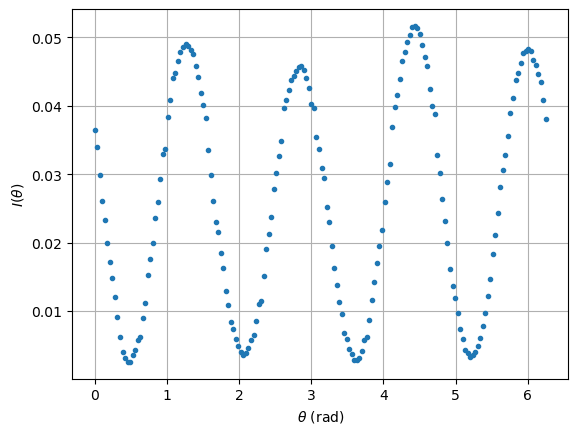

In [12]:
# ---  Data plot ---

plt.figure()
plt.plot(theta,I_med, '.')

plt.xlabel(r"$\theta$ (rad)")
plt.ylabel(r"$I(\theta)$")
plt.grid()


In [13]:
# --- fix S_0 ---
S0 = 2 * np.mean(np.sort(I_med)[-4:])
print(S0)

0.10251199999999999


S0 = 0.10251199999999999
S1 = -0.0507045614200978
S2 = -19652.869824026504
S3 = -0.5522108971503894
delta = 0.0029279094185337712


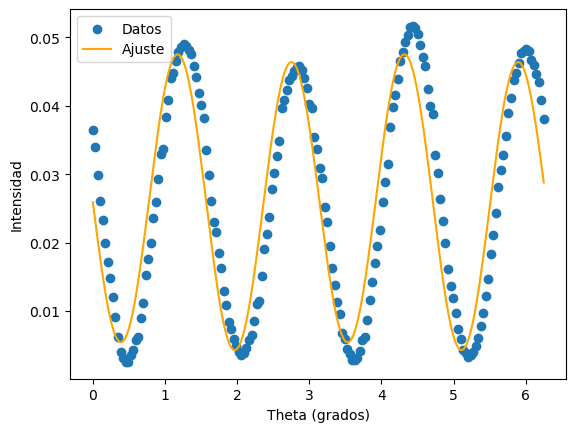

In [14]:
def model_intensity(theta, S1, S2, S3, delta):
    
    a0  = S0/2 + S1/4*(1 + np.cos(delta))
    a4c = S1/4*(1 - np.cos(delta))
    a4s = S2/4*(1 - np.cos(delta))
    a2  = -S3/2*np.sin(delta)
    
    return (
        a0
        + a2*np.sin(2*theta)
        + a4c*np.cos(4*theta)
        + a4s*np.sin(4*theta)
    )

def residuals(params):
    S1, S2, S3, delta = params
    return model_intensity(theta, S1, S2, S3, delta) - I_med

initial_guess = [
    0.1*S0,   # S1
    0.1*S0,   # S2
    0.1*S0,   # S3
    np.pi/4  # delta
]

from scipy.optimize import least_squares
result = least_squares(residuals, initial_guess)

S1_fit, S2_fit, S3_fit, delta_fit = result.x

print("S0 =", S0)
print("S1 =", S1_fit)
print("S2 =", S2_fit)
print("S3 =", S3_fit)
print("delta =", delta_fit)

theta_fit = np.linspace(theta.min(), theta.max(), 500)
I_fit = model_intensity(theta_fit, S1_fit, S2_fit, S3_fit, delta_fit)

plt.scatter(theta, I_med, label="Datos")
plt.plot((theta_fit), I_fit, label="Ajuste", color="orange")
plt.xlabel("Theta (grados)")
plt.ylabel("Intensidad")
plt.legend()

In [15]:
S0=0.10251199999999999
S1 = -0.050704563428085214
S2 = -19246.870403691646
S3 = -0.5464719356835321
delta = 0.002958716748901447

In [16]:
# --- calculate DOP ---
DOP2=(np.sqrt(S1**2+S2**2+S3**2))/S0
print(DOP2)

187752.364713559


## Another try

S0 = 0.034852994262725784
S1 = 0.0339090692523702
S2 = -0.08424534484831987
S3 = -0.0016168641712793039
DOP = 2.6060301740645144


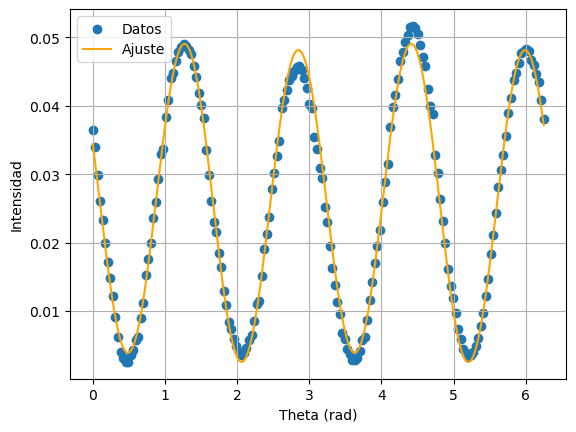

In [17]:
# --- get data ---
medicion = pd.read_csv('Measurements\\medicion_manual_v0.1.csv')

I_med = medicion['voltaje'].values
theta = medicion['angulo'].values * np.pi / 180  # radianes

# --- harmonic model ---
def model(theta, A0, A2, A4c, A4s):
    return A0 + A2*np.sin(2*theta) + A4c*np.cos(4*theta) + A4s*np.sin(4*theta)

# --- residuals ---
def residuals(params):
    A0, A2, A4c, A4s = params
    return model(theta, A0, A2, A4c, A4s) - I_med

# --- reazonable initial guesses ---
initial_guess = [
    np.mean(I_med),   # A0
    0.0,              # A2
    0.01,             # A4c
    0.01              # A4s
]

# --- fit ---
result = least_squares(residuals, initial_guess)
A0, A2, A4c, A4s = result.x

# --- reconstruction of effective Stokes parameters ---
S0 = 2*A0-2*A4c
S1 = 4*A4c
S2 = 4*A4s
S3 = -2*A2

print("S0 =", S0)
print("S1 =", S1)
print("S2 =", S2)
print("S3 =", S3)

# --- DOP ---
DOP = np.sqrt(S1**2 + S2**2 + S3**2) / S0
print("DOP =", DOP)

# --- fitted curve ---
theta_fit = np.linspace(theta.min(), theta.max(), 500)
I_fit = model(theta_fit, A0, A2, A4c, A4s)

# --- graph ---
plt.scatter(theta, I_med, label="Datos")
plt.plot(theta_fit, I_fit, label="Ajuste", color="orange")

plt.grid()
plt.xlabel("Theta (rad)")
plt.ylabel("Intensidad")
plt.legend()
plt.show()

## Fit using every quadrant $\delta$ as a parameter, adding to 7 parameters (using an estimated $\delta = \frac{\pi}{2}$)

S0 = 0.051807528888888815
S1 = 0.017315807282888066
S2 = -0.04478522987920335
S3 = -0.0074924893622947955

Deltas:
d1 = 2.882973203843275
d2 = 2.4086914444894814
d3 = 2.9862366783115255
d4 = 2.5454529524316913

DOP = 0.9380342496127403


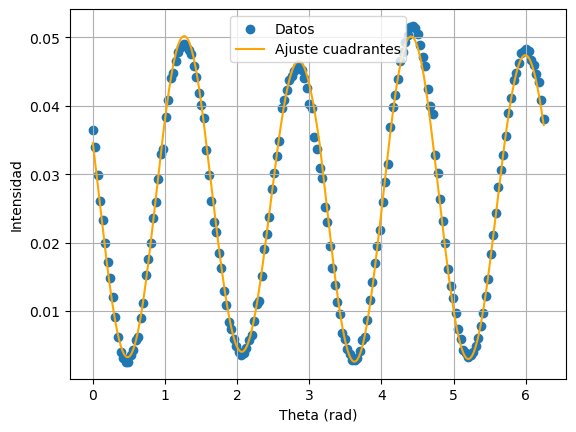

In [18]:
# --- get data ---
medicion = pd.read_csv('Measurements\\medicion_manual_v0.1.csv')

I_med = medicion['voltaje'].values
theta = medicion['angulo'].values * np.pi / 180  # rad

# --- estimate S0 ---
S0 = 2 * np.mean(I_med)

# --- delta function for every quadrant ---
def delta_por_cuadrante(theta, d1, d2, d3, d4):
    theta = theta % (2*np.pi)
    
    if 0 <= theta < np.pi/2:
        return d1
    elif np.pi/2 <= theta < np.pi:
        return d2
    elif np.pi <= theta < 3*np.pi/2:
        return d3
    else:
        return d4

# --- model ---
def model(theta, S1, S2, S3, d1, d2, d3, d4):
    I = []
    
    for t in theta:
        delta = delta_por_cuadrante(t, d1, d2, d3, d4)
        
        a0  = S0/2 + S1/4*(1 + np.cos(delta))
        a4c = S1/4*(1 - np.cos(delta))
        a4s = S2/4*(1 - np.cos(delta))
        a2  = -S3/2*np.sin(delta)
        
        I.append(
            a0
            + a2*np.sin(2*t)
            + a4c*np.cos(4*t)
            + a4s*np.sin(4*t)
        )
    
    return np.array(I)

# --- residuals ---
def residuals(params):
    S1, S2, S3, d1, d2, d3, d4 = params
    return model(theta, S1, S2, S3, d1, d2, d3, d4) - I_med

# --- initial conditions ---
initial_guess = [
    0.1*S0,  # S1
    0.1*S0,  # S2
    0.1*S0,  # S3
    np.pi/2, np.pi/2, np.pi/2, np.pi/2  # deltas
]

# --- bounds (KEY for stability) ---
lower_bounds = [
    -S0, -S0, -S0,
    0, 0, 0, 0
]

upper_bounds = [
    S0, S0, S0,
    2*np.pi, 2*np.pi, 2*np.pi, 2*np.pi
]

# --- fit ---
result = least_squares(
    residuals,
    initial_guess,
    bounds=(lower_bounds, upper_bounds)
)

S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit = result.x

print("S0 =", S0)
print("S1 =", S1_fit)
print("S2 =", S2_fit)
print("S3 =", S3_fit)

print("\nDeltas:")
print("d1 =", d1_fit)
print("d2 =", d2_fit)
print("d3 =", d3_fit)
print("d4 =", d4_fit)

# --- DOP ---
DOP = np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2) / S0
print("\nDOP =", DOP)

# --- fitted curve ---
theta_fit = np.linspace(theta.min(), theta.max(), 500)
I_fit = model(theta_fit, S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit)

# --- graph ---
plt.scatter(theta, I_med, label="Datos")
plt.plot(theta_fit, I_fit, color="orange", label="Ajuste cuadrantes")

plt.grid()
plt.xlabel("Theta (rad)")
plt.ylabel("Intensidad")
plt.legend()
plt.show()

## i remake the same adjustment but taking into account errors and residuals

S0 = 0.051807528888888815
S1 = 0.017315807282888066 ± 0.00030429257193211826
S2 = -0.04478522987920335 ± 0.00040916388782750453
S3 = -0.0074924893622947955 ± 0.0006164460529192854

Deltas:
d1 = 2.882973203843275 ± 0.04802713655123591
d2 = 2.4086914444894814 ± 0.04090720464207466
d3 = 2.9862366783115255 ± 0.055679334152994066
d4 = 2.5454529524316913 ± 0.0504917847544169

DOP = 0.9380342496127403


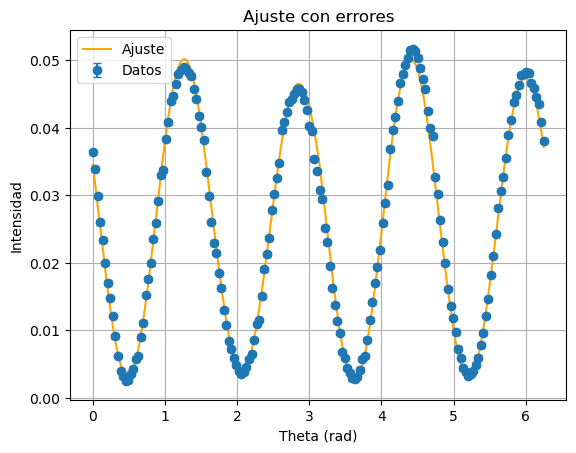

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# --- cargar datos ---
medicion = pd.read_csv('C:\\Users\\barcr\\Polarimetro\\Measurements\\medicion_manual_v0.1.csv')

I_med = medicion['voltaje'].values
theta = medicion['angulo'].values * np.pi / 180  # rad

# --- (opcional) error en intensidad ---
# si no tenés errores medidos, podés asumir uno constante:
sigma_I = np.std(I_med) * 0.02  # ajustá si querés
sigma_I_array = np.full_like(I_med, sigma_I)

# --- estimar S0 ---
S0 = 2 * np.mean(I_med)

# --- delta por cuadrante ---
def delta_por_cuadrante(theta, d1, d2, d3, d4):
    theta = theta % (2*np.pi)
    
    if 0 <= theta < np.pi/2:
        return d1
    elif np.pi/2 <= theta < np.pi:
        return d2
    elif np.pi <= theta < 3*np.pi/2:
        return d3
    else:
        return d4

# --- modelo ---
def model(theta, S1, S2, S3, d1, d2, d3, d4):
    I = []
    
    for t in theta:
        delta = delta_por_cuadrante(t, d1, d2, d3, d4)
        
        a0  = S0/2 + S1/4*(1 + np.cos(delta))
        a4c = S1/4*(1 - np.cos(delta))
        a4s = S2/4*(1 - np.cos(delta))
        a2  = -S3/2*np.sin(delta)
        
        I.append(
            a0
            + a2*np.sin(2*t)
            + a4c*np.cos(4*t)
            + a4s*np.sin(4*t)
        )
    
    return np.array(I)

# --- residuos ---
def residuals(params):
    S1, S2, S3, d1, d2, d3, d4 = params
    return (model(theta, S1, S2, S3, d1, d2, d3, d4) - I_med)

# --- condiciones iniciales ---
initial_guess = [
    0.1*S0,
    0.1*S0,
    0.1*S0,
    np.pi/2, np.pi/2, np.pi/2, np.pi/2
]

# --- bounds ---
lower_bounds = [-S0, -S0, -S0, 0, 0, 0, 0]
upper_bounds = [ S0,  S0,  S0, 2*np.pi, 2*np.pi, 2*np.pi, 2*np.pi]

# --- ajuste ---
result = least_squares(
    residuals,
    initial_guess,
    bounds=(lower_bounds, upper_bounds)
)

S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit = result.x

# --- errores ---
J = result.jac
res = result.fun
N = len(res)
p = len(result.x)

sigma2 = np.sum(res**2) / (N - p)
cov = sigma2 * np.linalg.inv(J.T @ J)
errors = np.sqrt(np.diag(cov))

S1_err, S2_err, S3_err, d1_err, d2_err, d3_err, d4_err = errors

# --- imprimir resultados ---
print("S0 =", S0)
print(f"S1 = {S1_fit} ± {S1_err}")
print(f"S2 = {S2_fit} ± {S2_err}")
print(f"S3 = {S3_fit} ± {S3_err}")

print("\nDeltas:")
print(f"d1 = {d1_fit} ± {d1_err}")
print(f"d2 = {d2_fit} ± {d2_err}")
print(f"d3 = {d3_fit} ± {d3_err}")
print(f"d4 = {d4_fit} ± {d4_err}")

# --- DOP ---
DOP = np.sqrt(S1_fit**2 + S2_fit**2 + S3_fit**2) / S0
print("\nDOP =", DOP)

# --- curva ajustada ---
theta_fit = np.linspace(theta.min(), theta.max(), 500)
I_fit = model(theta_fit, S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit)

# --- gráfico ---
plt.figure()
plt.errorbar(theta, I_med, yerr=sigma_I_array, fmt='o', label="Datos", capsize=3)
plt.plot(theta_fit, I_fit, color="orange", label="Ajuste")
plt.xlabel("Theta (rad)")
plt.ylabel("Intensidad")
plt.legend()
plt.title("Ajuste con errores")
plt.grid()
plt.show()

C:\Users\barcr\AppData\Local\Temp\ipykernel_30368\1966899464.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


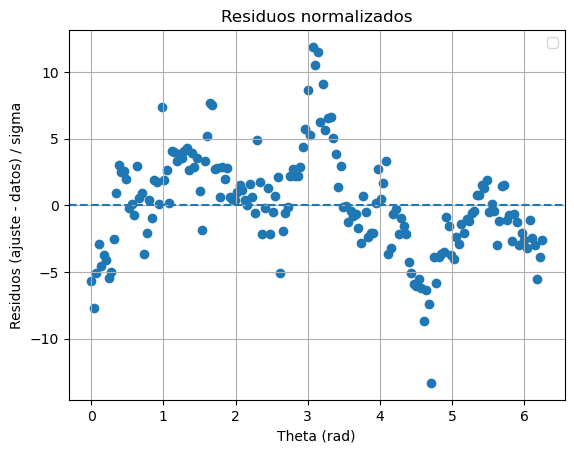

In [20]:
# --- residuos normalizados ---
residuos = (model(theta, S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit) - I_med) / sigma_I_array

# --- gráfico ---
plt.figure()
plt.scatter(theta, residuos)
plt.axhline(0, linestyle='--')
plt.xlabel("Theta (rad)")
plt.ylabel("Residuos (ajuste - datos) / sigma")
plt.title("Residuos normalizados")
plt.legend()
plt.grid()
plt.show()

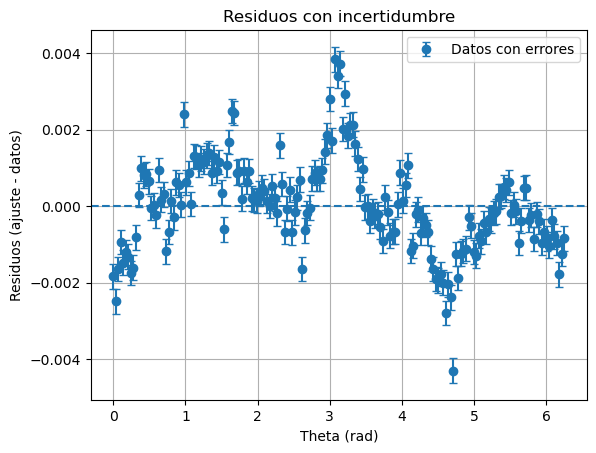

In [21]:
# --- residuos (crudos) ---
residuos = model(theta, S1_fit, S2_fit, S3_fit, d1_fit, d2_fit, d3_fit, d4_fit) - I_med

# --- gráfico con barras de error ---
plt.figure()
plt.errorbar(theta, residuos, yerr=sigma_I_array, fmt='o', capsize=3, label="Datos con errores")
plt.axhline(0, linestyle='--')
plt.xlabel("Theta (rad)")
plt.ylabel("Residuos (ajuste - datos)")
plt.title("Residuos con incertidumbre")
plt.grid()
plt.legend()
plt.show()